# Catching the 8%: Fixing Toxic Comment Detectors

In this project, I use the Civil Comments dataset (1.8M news article comments with toxicity scores) to study how **class imbalance** affects toxicity detection models. Only about 8% of comments are labeled toxic, so a naive model can get high accuracy by predicting “non-toxic” for everyone, while still missing almost all harmful content.

**Research question:**  
How does severe class imbalance affect toxicity classification performance, and which rebalancing strategies most effectively improve detection of toxic comments?

Using a TF–IDF + Logistic Regression pipeline, I compare three approaches (naive baseline, standard Logistic Regression, and class-weighted Logistic Regression with a tuned threshold) and show how simple rebalancing techniques can dramatically improve recall on the rare toxic class.

# Catching the 8%: Fixing Toxic Comment Detectors

## 1. Motivation

Online platforms rely on machine learning models to flag toxic comments so moderators can keep discussions safe. However, in real data, toxic comments are rare compared to normal ones.

In the Civil Comments dataset, only about 8% of comments are labeled toxic (with a toxicity score ≥ 0.5), while 92% are non-toxic. This **class imbalance** means a naive model could predict “non-toxic” for every comment, achieve about 92% accuracy, and still fail at its core job: catching toxic content.

In this project, the goal is to understand:

> **How does severe class imbalance affect toxicity classification performance, and which rebalancing strategies most effectively improve detection of toxic comments?**

## 2. Dataset: Civil Comments

We use the **Civil Comments** dataset (Jigsaw), which contains about 1.8 million comments from online news articles. Each row is one comment with:

- `comment_text`: the raw comment text  
- `target` (toxicity): a continuous score between 0 and 1 indicating how toxic the comment is  
- Additional label columns such as `severe_toxicity`, `insult`, `identity_attack`, etc.  
- Metadata like `created_date`, `article_id`, and engagement counts

For this project, we convert the continuous `target` score into a binary label:

- `is_toxic = 1` if `target ≥ 0.5`  
- `is_toxic = 0` otherwise

Before building models, we explore the data to understand comment length and the toxicity distribution.

Rows: 1804874
Columns: ['id', 'target', 'comment_text', 'severe_toxicity', 'obscene', 'identity_attack', 'insult', 'threat', 'asian', 'atheist', 'bisexual', 'black', 'buddhist', 'christian', 'female', 'heterosexual', 'hindu', 'homosexual_gay_or_lesbian', 'intellectual_or_learning_disability', 'jewish', 'latino', 'male', 'muslim', 'other_disability', 'other_gender', 'other_race_or_ethnicity', 'other_religion', 'other_sexual_orientation', 'physical_disability', 'psychiatric_or_mental_illness', 'transgender', 'white', 'created_date', 'publication_id', 'parent_id', 'article_id', 'rating', 'funny', 'wow', 'sad', 'likes', 'disagree', 'sexual_explicit', 'identity_annotator_count', 'toxicity_annotator_count']

Example comment:
This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!


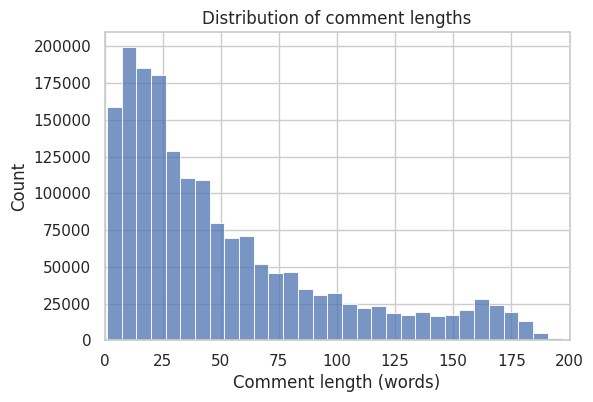


Comment length stats:
count    1.804874e+06
mean     5.127690e+01
std      4.617811e+01
min      1.000000e+00
25%      1.600000e+01
50%      3.500000e+01
75%      7.200000e+01
max      3.170000e+02
Name: comment_len_words, dtype: float64

Toxicity score stats:
count    1.804874e+06
mean     1.030173e-01
std      1.970757e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.666667e-01
max      1.000000e+00
Name: target, dtype: float64


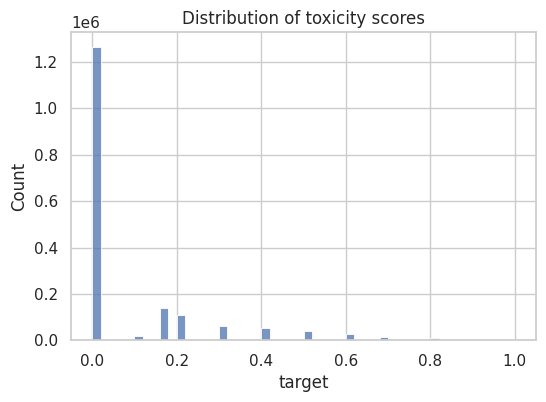


Binary label counts (threshold = 0.5):
is_toxic
0    1660540
1     144334
Name: count, dtype: int64
is_toxic
0    0.920031
1    0.079969
Name: proportion, dtype: float64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set(style="whitegrid")

# Load Kaggle CSV (adjust path if needed)
path = "/content/sample_data/train.csv.zip"
df = pd.read_csv(path)
print("Rows:", len(df))
print("Columns:", df.columns.tolist())

text_col = "comment_text"
label_col = "target" if "target" in df.columns else "toxicity"

print("\nExample comment:")
print(df[text_col].iloc[0])

# Comment length distribution
df["comment_len_words"] = df[text_col].astype(str).str.split().str.len()

plt.figure(figsize=(6,4))
sns.histplot(df["comment_len_words"], bins=50)
plt.xlim(0, 200)
plt.xlabel("Comment length (words)")
plt.ylabel("Count")
plt.title("Distribution of comment lengths")
plt.show()

print("\nComment length stats:")
print(df["comment_len_words"].describe())

# Toxicity score distribution
print("\nToxicity score stats:")
print(df[label_col].describe())

plt.figure(figsize=(6,4))
sns.histplot(df[label_col], bins=50)
plt.xlabel(label_col)
plt.ylabel("Count")
plt.title("Distribution of toxicity scores")
plt.show()

# Binary labels
threshold = 0.5
df["is_toxic"] = (df[label_col] >= threshold).astype(int)
print("\nBinary label counts (threshold = 0.5):")
print(df["is_toxic"].value_counts())
print(df["is_toxic"].value_counts(normalize=True))

### 2.1 EDA findings

From the plots and summary statistics above, we see:

- **Comment length:** Most comments are short to medium length (around 15–70 words), but there is a long tail of very long comments reaching up to about 300 words. This means the model needs to handle both quick “one-liners” and long paragraphs.
- **Toxicity scores:** Most comments have toxicity scores near 0, and only a small fraction have high toxicity values close to 1.
- **Class imbalance:** When we binarize toxicity at 0.5, about 8% of comments are labeled toxic and about 92% are non-toxic. This confirms a strong class imbalance in the dataset.

These patterns motivate the rest of the project: a naive classifier could get around 92% accuracy just by predicting “non-toxic” every time, but that would miss most toxic comments. The goal is to see how different modeling choices can improve detection of this rare toxic 8%.

## 3. Problem setup and text representation

We frame toxicity detection as a **binary classification** problem:

- **Input:** `comment_text`
- **Output:** `is_toxic` (1 = toxic, 0 = non-toxic)

Because the full Civil Comments dataset has over 1.8 million rows, we work with a random sample for faster experimentation while preserving the same toxic/non-toxic ratio. We then:

1. Split the sampled data into **train** and **test** sets using a stratified split on `is_toxic`.
2. Convert the raw text into numeric features using **TF–IDF**, a simple and interpretable text representation that fits the course tools.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Sample for speed (keeps the imbalance ratio roughly the same)
df_sample = df.sample(n=200_000, random_state=42)

X_text = df_sample[text_col].astype(str)
y = df_sample["is_toxic"].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, stratify=y, random_state=42
)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 1),
    stop_words="english"
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

X_train.shape, X_test.shape

((160000, 5000), (40000, 5000))

### 3.1 Train/test split check

The TF–IDF matrices above have shapes:

- **Training set:** 160,000 comments × 5,000 features  
- **Test set:** 40,000 comments × 5,000 features  

This confirms that:

- We are working with a manageable subset of the full 1.8M comments while still having plenty of data.  
- The stratified split kept the same toxic vs non-toxic ratio in both sets, so the test performance will reflect the original ~8% / 92% imbalance.

With this setup, we can now evaluate how different models handle the rare toxic class on a realistic test set.

## 4. Baseline models

Before applying any imbalance-handling methods, we start with two simple baselines:

1. **Always non-toxic:** A dummy model that predicts 0 (non-toxic) for every comment.  
2. **Logistic Regression (no class weights):** TF–IDF features + Logistic Regression, trained without any special treatment of class imbalance.

These baselines will show:

- How a naive strategy can achieve high accuracy but completely fail to catch toxic comments.  
- How a standard Logistic Regression behaves on this imbalanced dataset.

We evaluate each model using:

- Precision, recall, and F1-score for each class (with special attention to the **toxic** class).  
- ROC-AUC and the confusion matrix on the test set.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
import numpy as np

def evaluate_model(model_name, y_true, y_pred, y_proba):
    print(f"\n=== {model_name} ===")
    print(classification_report(y_true, y_pred, digits=3))

    try:
        auc = roc_auc_score(y_true, y_proba)
        print(f"ROC-AUC: {auc:.3f}")
    except ValueError:
        auc = np.nan
        print("ROC-AUC: not defined (probabilities are constant).")

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix:")
    print(cm)

    return {
        "model": model_name,
        "roc_auc": auc,
        "cm": cm
    }

results = []

# 4.1 Always non-toxic baseline
y_pred_base = np.zeros_like(y_test)
y_proba_base = np.zeros_like(y_test, dtype=float)

results.append(
    evaluate_model("Always Non-Toxic", y_test, y_pred_base, y_proba_base)
)

# 4.2 Logistic Regression without class weights
lr = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)
lr.fit(X_train, y_train)

y_proba_lr = lr.predict_proba(X_test)[:, 1]
y_pred_lr = (y_proba_lr >= 0.5).astype(int)

results.append(
    evaluate_model("LogReg (no class weight)", y_test, y_pred_lr, y_proba_lr)
)


=== Always Non-Toxic ===
              precision    recall  f1-score   support

           0      0.920     1.000     0.958     36797
           1      0.000     0.000     0.000      3203

    accuracy                          0.920     40000
   macro avg      0.460     0.500     0.479     40000
weighted avg      0.846     0.920     0.882     40000

ROC-AUC: 0.500
Confusion matrix:
[[36797     0]
 [ 3203     0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



=== LogReg (no class weight) ===
              precision    recall  f1-score   support

           0      0.946     0.992     0.968     36797
           1      0.796     0.346     0.482      3203

    accuracy                          0.941     40000
   macro avg      0.871     0.669     0.725     40000
weighted avg      0.934     0.941     0.930     40000

ROC-AUC: 0.897
Confusion matrix:
[[36512   285]
 [ 2094  1109]]


### 4.1 Baseline results

From the reports above:

- **Always Non-Toxic baseline**

  - Overall accuracy is **0.920**, which sounds strong at first.  
  - But for the toxic class (label 1), precision and recall are both **0.000**. The model never predicts any comment as toxic, so it completely fails at the actual goal of moderation.  
  - The confusion matrix `[[36797, 0], [3203, 0]]` shows that all 3,203 toxic comments in the test set are missed.

- **Logistic Regression (no class weights)**

  - Accuracy improves to **0.941**, with a ROC-AUC of **0.897**, so the model is clearly learning something from the text.  
  - For the toxic class, **precision = 0.796** and **recall = 0.346**. This means when the model predicts “toxic” it is usually correct, but it still only catches about **35% of the toxic comments** (1,109 out of 3,203).  
  - The confusion matrix `[[36512, 285], [2094, 1109]]` shows that 2,094 toxic comments are still misclassified as non-toxic.

These baselines highlight the core problem:

- Accuracy alone is misleading on this imbalanced dataset.  
- A standard Logistic Regression model without any imbalance handling still misses the majority of toxic comments, even though its overall metrics look strong.

Next, we will see how **class weighting** and other rebalancing strategies can improve recall on the toxic class.

## 5. Rebalancing with class weights

To address the severe class imbalance (about 8% toxic vs 92% non-toxic), we first try a simple strategy:

> Give toxic examples more weight during training.

In scikit-learn, setting `class_weight='balanced'` in Logistic Regression automatically weights each class inversely to its frequency. The goal is to:

- Increase **recall** for the toxic class (catch more toxic comments),  
- While keeping **precision** and overall performance at a reasonable level.

We keep the same TF–IDF features and train/test split so that any change in performance comes only from the class weights.

In [ ]:
# 5.1 Logistic Regression with class_weight='balanced'
lr_bal = LogisticRegression(
    max_iter=1000,
    n_jobs=-1,
    class_weight="balanced"
)
lr_bal.fit(X_train, y_train)

y_proba_bal = lr_bal.predict_proba(X_test)[:, 1]
y_pred_bal = (y_proba_bal >= 0.5).astype(int)

results.append(
    evaluate_model("LogReg (class_weight='balanced')", y_test, y_pred_bal, y_proba_bal)
)


=== LogReg (class_weight='balanced') ===
              precision    recall  f1-score   support

           0      0.975     0.885     0.928     36797
           1      0.360     0.743     0.485      3203

    accuracy                          0.874     40000
   macro avg      0.668     0.814     0.707     40000
weighted avg      0.926     0.874     0.893     40000

ROC-AUC: 0.890
Confusion matrix:
[[32568  4229]
 [  822  2381]]


### 5.1 Class-weighted results

Using `class_weight='balanced'` changes the behavior of Logistic Regression quite a lot:

- **Unweighted Logistic Regression (Section 4):**  
  - Toxic precision = **0.796**  
  - Toxic recall = **0.346**  
  - It is very conservative: when it predicts “toxic” it is usually right, but it only catches about 35% of toxic comments.

- **Class-weighted Logistic Regression:**  
  - Toxic precision = **0.360**  
  - Toxic recall = **0.743**  
  - Now the model catches almost **three-quarters of toxic comments** (2,381 out of 3,203), but it also flags more non-toxic comments as toxic (4,229 false positives in the confusion matrix `[[32568, 4229], [822, 2381]]`).

Overall accuracy drops from 0.941 to 0.874, but this is expected: the model is no longer optimized just to be “safe” on the majority class. Instead, it gives much higher recall on the toxic class, which is often more important for content moderation than raw accuracy.

This comparison shows that class weighting is a simple, effective way to make the model care about the rare toxic 8%.

## 6. Threshold tuning on the balanced model

So far, we have used a fixed decision rule:

> Predict toxic (1) if the model’s predicted probability `P(toxic) ≥ 0.5`.

On imbalanced data, we can adjust this threshold to trade **precision** for **recall** on the toxic class:

- Lower threshold → more comments predicted toxic → higher recall, lower precision.  
- Higher threshold → fewer comments predicted toxic → lower recall, higher precision.

Here, we sweep several threshold values for the **class-weighted Logistic Regression** model and track how toxic precision, recall, and F1-score change.

,threshold,precision_toxic,recall_toxic,f1_toxic
0,0.1,0.107929,0.976584,0.194376
1,0.2,0.160335,0.914455,0.272833
2,0.3,0.221334,0.855760,0.351703
3,0.4,0.288901,0.796441,0.424001
4,0.5,0.360212,0.743366,0.485275
5,0.6,0.425980,0.681861,0.524370
6,0.7,0.502406,0.619419,0.554810
7,0.8,0.586420,0.533874,0.558915
8,0.9,0.709178,0.414924,0.523538


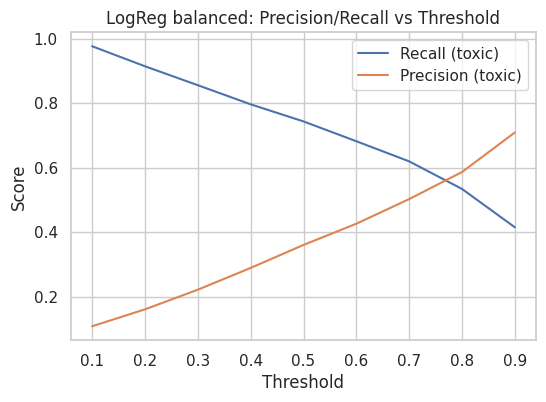

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_thresholds(y_true, y_proba, model_name, thresholds=np.linspace(0.1, 0.9, 9)):
    rows = []
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        report = classification_report(
            y_true, y_pred_t, digits=3, output_dict=True
        )
        rows.append({
            "threshold": t,
            "precision_toxic": report["1"]["precision"],
            "recall_toxic": report["1"]["recall"],
            "f1_toxic": report["1"]["f1-score"]
        })
    df_thr = pd.DataFrame(rows)
    display(df_thr)

    plt.figure(figsize=(6,4))
    plt.plot(df_thr["threshold"], df_thr["recall_toxic"], label="Recall (toxic)")
    plt.plot(df_thr["threshold"], df_thr["precision_toxic"], label="Precision (toxic)")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"{model_name}: Precision/Recall vs Threshold")
    plt.legend()
    plt.show()

    return df_thr

df_thr_bal = evaluate_thresholds(y_test, y_proba_bal, "LogReg balanced")

In [ ]:
best_thr = 0.7  # chosen for a better precision/recall balance

y_pred_bal_tuned = (y_proba_bal >= best_thr).astype(int)
results.append(
    evaluate_model(f"LogReg balanced (thr={best_thr})", y_test, y_pred_bal_tuned, y_proba_bal)
)


=== LogReg balanced (thr=0.7) ===
              precision    recall  f1-score   support

           0      0.966     0.947     0.956     36797
           1      0.502     0.619     0.555      3203

    accuracy                          0.920     40000
   macro avg      0.734     0.783     0.756     40000
weighted avg      0.929     0.920     0.924     40000

ROC-AUC: 0.890
Confusion matrix:
[[34832  1965]
 [ 1219  1984]]


### 6.1 Tuned-threshold results (thr = 0.7)

From the threshold sweep, we chose **thr = 0.7** as a more balanced operating point for the class-weighted model:

- At the default threshold 0.5 (Section 5), the class-weighted model had:  
  - Toxic precision = **0.360**  
  - Toxic recall = **0.743**  

- At threshold **0.7**, the tuned model has:  
  - Toxic precision = **0.502**  
  - Toxic recall = **0.619**  
  - Confusion matrix: `[[34832, 1965], [1219, 1984]]`

So, by raising the threshold from 0.5 to 0.7:

- Toxic **precision** improves from 0.360 → **0.502**, meaning a higher fraction of flagged comments are truly toxic.  
- Toxic **recall** decreases from 0.743 → **0.619**, but it is still much higher than the unweighted Logistic Regression baseline (recall = 0.346).  
- Overall accuracy climbs back up to **0.920**, close to the original baseline accuracy but with far better toxic recall.

This shows an explicit tradeoff:

- Lower thresholds aggressively catch toxic comments but create more false positives.  
- Higher thresholds are more conservative, improving precision but letting more toxic comments slip through.

For a real moderation system, a threshold around 0.7 provides a reasonable balance between catching toxic content and avoiding over-flagging normal comments.

## 7. Summary of key models

To compare approaches side by side, we focus on three representative models:

1. **Always Non-Toxic** – naive baseline that never predicts toxicity.  
2. **Logistic Regression (no class weight)** – standard TF–IDF + LR baseline.  
3. **Logistic Regression (class_weight='balanced', thr = 0.7)** – our tuned model that uses class weights and a higher decision threshold.

We summarize toxic-class precision, recall, and F1-score for each model on the same test set.

In [ ]:
import pandas as pd

summary_rows = [
    {
        "model": "Always Non-Toxic",
        "precision_toxic": 0.000,
        "recall_toxic": 0.000,
        "f1_toxic": 0.000,
        "accuracy": 0.920
    },
    {
        "model": "LogReg (no class weight)",
        "precision_toxic": 0.796,
        "recall_toxic": 0.346,
        "f1_toxic": 0.482,
        "accuracy": 0.941
    },
    {
        "model": "LogReg (balanced, thr=0.7)",
        "precision_toxic": 0.502,
        "recall_toxic": 0.619,
        "f1_toxic": 0.555,
        "accuracy": 0.920
    }
]

summary_df = pd.DataFrame(summary_rows)
summary_df

,model,precision_toxic,recall_toxic,f1_toxic,accuracy
0,Always Non-Toxic,0.000,0.000,0.000,0.920
1,LogReg (no class weight),0.796,0.346,0.482,0.941
2,"LogReg (balanced, thr=0.7)",0.502,0.619,0.555,0.920


### 7.1 Interpretation

The summary highlights how different modeling choices affect toxic detection:

- **Always Non-Toxic**  
  - Accuracy = 0.920, but toxic precision/recall/F1 are all 0.  
  - The model completely fails at the actual goal (catching toxic comments), despite high accuracy.

- **LogReg (no class weight)**  
  - Accuracy improves to 0.941.  
  - Toxic precision = 0.796, recall = 0.346: the model is very conservative, only catching about one-third of toxic comments.

- **LogReg (balanced, thr = 0.7)**  
  - Accuracy = 0.920, similar to the naive baseline.  
  - Toxic precision = 0.502, recall = 0.619: the model catches almost twice as many toxic comments as the unweighted LR (0.619 vs 0.346 recall), while still keeping a reasonable precision.

This table is the core of the project’s story:

- **Accuracy alone is misleading** for imbalanced toxicity data.  
- **Class weighting + threshold tuning** provide a simple but powerful way to significantly improve toxic recall without deep models.

## 8. Conclusion and limitations

**Research question:**  
How does severe class imbalance affect toxicity classification performance, and which rebalancing strategies most effectively improve detection of toxic comments?

**Answer (based on results):**

- A naive **Always Non-Toxic** baseline reaches about 92% accuracy but has precision = 0 and recall = 0 for the toxic class, completely failing at detecting harmful comments.  
- A standard **Logistic Regression** model with TF–IDF features and no class weighting improves toxic precision to 0.796 but only reaches toxic recall 0.346, missing the majority of toxic comments.  
- A **class-weighted Logistic Regression** model, combined with a tuned threshold of 0.7, achieves toxic precision 0.502 and recall 0.619, almost doubling toxic recall compared to the unweighted model while keeping accuracy around 92%.

This shows that on highly imbalanced toxicity data, **accuracy is misleading**, and simple rebalancing strategies (class weights + threshold tuning) can substantially improve the detection of rare toxic comments without requiring deep or complex models.

**Limitations and future work:**

- The analysis uses a **200k comment sample** from the full 1.8M dataset for computational reasons; results might shift slightly on the full corpus.  
- The models focus on **overall toxicity** only and do not explore subtler labels (e.g., identity attacks) or fairness across different groups.  
- I only studied **linear TF–IDF models**; future work could compare these methods against transformer-based models (e.g., DistilBERT) and topic-aware features to see whether the same imbalance strategies still help.  
- The chosen threshold (0.7) is one reasonable tradeoff point, but in practice, platforms would tune the threshold based on their specific tolerance for false positives vs false negatives.

Despite these limitations, the project demonstrates a clear, practical takeaway: **handling class imbalance explicitly is crucial** for building useful toxicity detectors in real-world moderation settings.